In [1]:
from google.colab import files

uploaded = files.upload()

Saving fraudTrain.csv.zip to fraudTrain.csv.zip
Saving fraudTest.csv.zip to fraudTest.csv.zip


In [2]:
import zipfile
import os

# File paths
train_zip = "/content/fraudTrain.csv.zip"
test_zip = "/content/fraudTest.csv.zip"

# Extract locations
train_folder = "/content/fraud_train"
test_folder = "/content/fraud_test"

# Extract training data
with zipfile.ZipFile(train_zip, "r") as zip_ref:
    zip_ref.extractall(train_folder)

# Extract testing data
with zipfile.ZipFile(test_zip, "r") as zip_ref:
    zip_ref.extractall(test_folder)

print("Training dataset extracted successfully!")
print("Testing dataset extracted successfully!")

print("\nTraining folder:", os.listdir(train_folder))
print("Testing folder:", os.listdir(test_folder))

Training dataset extracted successfully!
Testing dataset extracted successfully!

Training folder: ['fraudTrain.csv']
Testing folder: ['fraudTest.csv']


In [3]:
import pandas as pd

train_path = "/content/fraud_train/fraudTrain.csv"
test_path = "/content/fraud_test/fraudTest.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (1296675, 23)
Testing Dataset Shape: (555719, 23)


In [4]:
print("Training Dataset Columns:")
print(train_df.columns.tolist())

Training Dataset Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [5]:
print("Fraud Distribution:")
print(train_df["is_fraud"].value_counts())

print("\nFraud Percentage:")
print(train_df["is_fraud"].value_counts(normalize=True) * 100)

Fraud Distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud Percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


In [6]:
print("Missing Values:")
print(train_df.isnull().sum())

Missing Values:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [7]:
print("Duplicate Rows:", train_df.duplicated().sum())

Duplicate Rows: 0


In [8]:
train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

test_df["trans_date_trans_time"] = pd.to_datetime(
    test_df["trans_date_trans_time"]
)

print(train_df["trans_date_trans_time"].dtype)
print(train_df["trans_date_trans_time"].head())

datetime64[ns]
0   2019-01-01 00:00:18
1   2019-01-01 00:00:44
2   2019-01-01 00:00:51
3   2019-01-01 00:01:16
4   2019-01-01 00:03:06
Name: trans_date_trans_time, dtype: datetime64[ns]


In [9]:
train_df["hour"] = train_df["trans_date_trans_time"].dt.hour
train_df["day"] = train_df["trans_date_trans_time"].dt.day
train_df["month"] = train_df["trans_date_trans_time"].dt.month
train_df["day_of_week"] = train_df["trans_date_trans_time"].dt.dayofweek

test_df["hour"] = test_df["trans_date_trans_time"].dt.hour
test_df["day"] = test_df["trans_date_trans_time"].dt.day
test_df["month"] = test_df["trans_date_trans_time"].dt.month
test_df["day_of_week"] = test_df["trans_date_trans_time"].dt.dayofweek

print(train_df[["trans_date_trans_time", "hour", "day", "month", "day_of_week"]].head())

  trans_date_trans_time  hour  day  month  day_of_week
0   2019-01-01 00:00:18     0    1      1            1
1   2019-01-01 00:00:44     0    1      1            1
2   2019-01-01 00:00:51     0    1      1            1
3   2019-01-01 00:01:16     0    1      1            1
4   2019-01-01 00:03:06     0    1      1            1


In [10]:
train_df.drop("trans_date_trans_time", axis=1, inplace=True)
test_df.drop("trans_date_trans_time", axis=1, inplace=True)

print("Column removed successfully!")
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Column removed successfully!
Training Dataset Shape: (1296675, 26)
Testing Dataset Shape: (555719, 26)


In [11]:
columns_to_drop = [
    "Unnamed: 0",
    "cc_num",
    "first",
    "last",
    "street",
    "trans_num",
    "unix_time"
]

train_df.drop(columns=columns_to_drop, axis=1, inplace=True)
test_df.drop(columns=columns_to_drop, axis=1, inplace=True)

print("Unnecessary columns removed successfully!")

print("\nRemaining Columns:")
print(train_df.columns.tolist())

print("\nTraining Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

Unnecessary columns removed successfully!

Remaining Columns:
['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day', 'month', 'day_of_week']

Training Shape: (1296675, 19)
Testing Shape: (555719, 19)


In [12]:
train_df["dob"] = pd.to_datetime(train_df["dob"])
test_df["dob"] = pd.to_datetime(test_df["dob"])

print(train_df["dob"].dtype)
print(train_df["dob"].head())

datetime64[ns]
0   1988-03-09
1   1978-06-21
2   1962-01-19
3   1967-01-12
4   1986-03-28
Name: dob, dtype: datetime64[ns]


In [13]:
train_df["age"] = 2020 - train_df["dob"].dt.year
test_df["age"] = 2020 - test_df["dob"].dt.year

print(train_df[["dob", "age"]].head())

         dob  age
0 1988-03-09   32
1 1978-06-21   42
2 1962-01-19   58
3 1967-01-12   53
4 1986-03-28   34


In [14]:
train_df.drop("dob", axis=1, inplace=True)
test_df.drop("dob", axis=1, inplace=True)

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)
print(train_df.columns.tolist())

Training Shape: (1296675, 19)
Testing Shape: (555719, 19)
['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day', 'month', 'day_of_week', 'age']


In [15]:
X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1296675, 18)
y_train Shape: (1296675,)
X_test Shape: (555719, 18)
y_test Shape: (555719,)


In [16]:
print("Categorical Columns:")
print(X_train.select_dtypes(include=["object"]).columns.tolist())

print("\nNumerical Columns:")
print(X_train.select_dtypes(exclude=["object"]).columns.tolist())

Categorical Columns:
['merchant', 'category', 'gender', 'city', 'state', 'job']

Numerical Columns:
['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'hour', 'day', 'month', 'day_of_week', 'age']


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_columns = [
    "merchant",
    "category",
    "gender",
    "city",
    "state",
    "job"
]

numerical_columns = [
    "amt",
    "zip",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long",
    "hour",
    "day",
    "month",
    "day_of_week",
    "age"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("numerical", StandardScaler(), numerical_columns)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")
print(f"Training data shape: {X_train_processed.shape}")
print(f"Testing data shape: {X_test_processed.shape}")

Preprocessing completed successfully.
Training data shape: (1296675, 2160)
Testing data shape: (555719, 2160)


In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

model.fit(X_train_processed, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [22]:
y_pred = model.predict(X_test_processed)

print("Predictions generated successfully.")
print(f"Total predictions: {len(y_pred)}")

Predictions generated successfully.
Total predictions: 555719


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9096
Precision: 0.0089
Recall   : 0.2033
F1-Score : 0.0171


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[505027  48547]
 [  1709    436]]


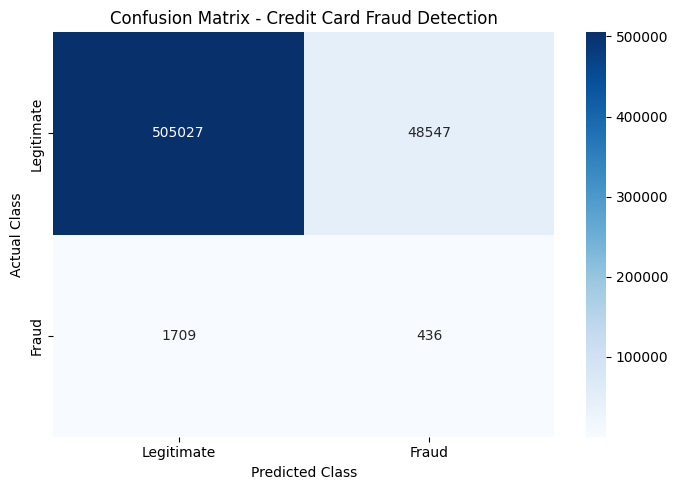

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Credit Card Fraud Detection")
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.5372


In [27]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print(f"PR-AUC Score: {pr_auc:.4f}")

PR-AUC Score: 0.0077


In [28]:
print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

Minimum probability: 1.20845755920305e-09
Maximum probability: 1.0
Mean probability: 0.15083379733436778


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    y_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_threshold, zero_division=0)
    recall = recall_score(y_test, y_threshold, zero_division=0)
    f1 = f1_score(y_test, y_threshold, zero_division=0)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("-" * 40)

Threshold: 0.1
Precision: 0.0038
Recall: 0.3935
F1-Score: 0.0075
----------------------------------------
Threshold: 0.2
Precision: 0.0044
Recall: 0.3170
F1-Score: 0.0087
----------------------------------------
Threshold: 0.3
Precision: 0.0054
Recall: 0.2741
F1-Score: 0.0107
----------------------------------------
Threshold: 0.4
Precision: 0.0068
Recall: 0.2350
F1-Score: 0.0132
----------------------------------------
Threshold: 0.5
Precision: 0.0089
Recall: 0.2033
F1-Score: 0.0171
----------------------------------------


In [30]:
import numpy as np

threshold_values = np.arange(0.01, 1.00, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in threshold_values:
    y_threshold = (y_prob >= threshold).astype(int)
    current_f1 = f1_score(y_test, y_threshold, zero_division=0)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-Score: {best_f1:.4f}")

Best Threshold: 0.92
Best F1-Score: 0.0431


In [31]:
best_predictions = (y_prob >= best_threshold).astype(int)

best_precision = precision_score(
    y_test,
    best_predictions,
    zero_division=0
)

best_recall = recall_score(
    y_test,
    best_predictions,
    zero_division=0
)

best_f1 = f1_score(
    y_test,
    best_predictions,
    zero_division=0
)

print(f"Threshold: {best_threshold:.2f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")
print(f"F1-Score: {best_f1:.4f}")

Threshold: 0.92
Precision: 0.0325
Recall: 0.0639
F1-Score: 0.0431


In [32]:
best_cm = confusion_matrix(y_test, best_predictions)

print("Confusion Matrix:")
print(best_cm)

tn, fp, fn, tp = best_cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

Confusion Matrix:
[[549499   4075]
 [  2008    137]]
True Negatives : 549499
False Positives: 4075
False Negatives: 2008
True Positives : 137


In [33]:
results = pd.DataFrame({
    "Threshold": [0.50, best_threshold],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        best_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        best_recall
    ],
    "F1-Score": [
        f1_score(y_test, y_pred, zero_division=0),
        best_f1
    ]
})

print(results.to_string(index=False))

 Threshold  Precision   Recall  F1-Score
      0.50   0.008901 0.203263  0.017055
      0.92   0.032526 0.063869  0.043102


In [34]:
print("Credit Card Fraud Detection - Baseline Model")
print("=" * 50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Best F1 Threshold: {best_threshold:.2f}")
print(f"Best F1-Score    : {best_f1:.4f}")

Credit Card Fraud Detection - Baseline Model
Accuracy  : 0.9096
Precision : 0.0089
Recall    : 0.2033
F1-Score  : 0.0171
ROC-AUC   : 0.5372
PR-AUC    : 0.0077
Best F1 Threshold: 0.92
Best F1-Score    : 0.0431


In [35]:
print("Processed training data type:", type(X_train_processed))
print("Processed testing data type:", type(X_test_processed))

Processed training data type: <class 'scipy.sparse._csr.csr_matrix'>
Processed testing data type: <class 'scipy.sparse._csr.csr_matrix'>


In [36]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

sgd_model.fit(X_train_processed, y_train)

print("SGD model training completed successfully.")

SGD model training completed successfully.


In [37]:
sgd_pred = sgd_model.predict(X_test_processed)

print("SGD predictions generated successfully.")
print(f"Total predictions: {len(sgd_pred)}")

SGD predictions generated successfully.
Total predictions: 555719


In [38]:
sgd_accuracy = accuracy_score(y_test, sgd_pred)
sgd_precision = precision_score(y_test, sgd_pred, zero_division=0)
sgd_recall = recall_score(y_test, sgd_pred, zero_division=0)
sgd_f1 = f1_score(y_test, sgd_pred, zero_division=0)

print(f"Accuracy : {sgd_accuracy:.4f}")
print(f"Precision: {sgd_precision:.4f}")
print(f"Recall   : {sgd_recall:.4f}")
print(f"F1-Score : {sgd_f1:.4f}")

Accuracy : 0.9254
Precision: 0.0329
Recall   : 0.6466
F1-Score : 0.0627


In [39]:
sgd_prob = sgd_model.predict_proba(X_test_processed)[:, 1]

sgd_roc_auc = roc_auc_score(y_test, sgd_prob)
sgd_pr_auc = average_precision_score(y_test, sgd_prob)

print(f"ROC-AUC: {sgd_roc_auc:.4f}")
print(f"PR-AUC : {sgd_pr_auc:.4f}")

ROC-AUC: 0.8435
PR-AUC : 0.0779


In [40]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SGD Classifier"
    ],
    "Accuracy": [
        accuracy,
        sgd_accuracy
    ],
    "Precision": [
        precision,
        sgd_precision
    ],
    "Recall": [
        recall,
        sgd_recall
    ],
    "F1-Score": [
        f1,
        sgd_f1
    ],
    "ROC-AUC": [
        roc_auc,
        sgd_roc_auc
    ],
    "PR-AUC": [
        pr_auc,
        sgd_pr_auc
    ]
})

print(model_comparison.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
Logistic Regression  0.909566   0.008901 0.203263  0.017055 0.537153 0.007698
     SGD Classifier  0.925351   0.032935 0.646620  0.062678 0.843524 0.077883


In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

threshold_values = np.arange(0.01, 1.00, 0.01)

sgd_threshold_results = []

for threshold in threshold_values:
    sgd_threshold_pred = (sgd_prob >= threshold).astype(int)

    sgd_threshold_precision = precision_score(
        y_test,
        sgd_threshold_pred,
        zero_division=0
    )

    sgd_threshold_recall = recall_score(
        y_test,
        sgd_threshold_pred,
        zero_division=0
    )

    sgd_threshold_f1 = f1_score(
        y_test,
        sgd_threshold_pred,
        zero_division=0
    )

    sgd_threshold_results.append([
        threshold,
        sgd_threshold_precision,
        sgd_threshold_recall,
        sgd_threshold_f1
    ])

sgd_threshold_df = pd.DataFrame(
    sgd_threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print(sgd_threshold_df.sort_values(
    "F1-Score",
    ascending=False
).head(10).to_string(index=False))

 Threshold  Precision   Recall  F1-Score
      0.91   0.157000 0.365967  0.219734
      0.89   0.152760 0.388345  0.219268
      0.90   0.154612 0.376690  0.219238
      0.93   0.160390 0.337529  0.217450
      0.88   0.149701 0.396270  0.217308
      0.92   0.156912 0.348718  0.216435
      0.87   0.146915 0.405128  0.215633
      0.86   0.144925 0.415385  0.214880
      0.94   0.160114 0.315152  0.212345
      0.85   0.141226 0.420979  0.211500


In [42]:
best_sgd_threshold = 0.91

sgd_best_pred = (sgd_prob >= best_sgd_threshold).astype(int)

sgd_best_accuracy = accuracy_score(y_test, sgd_best_pred)
sgd_best_precision = precision_score(y_test, sgd_best_pred, zero_division=0)
sgd_best_recall = recall_score(y_test, sgd_best_pred, zero_division=0)
sgd_best_f1 = f1_score(y_test, sgd_best_pred, zero_division=0)

print("Best SGD Threshold:", best_sgd_threshold)
print("Accuracy :", sgd_best_accuracy)
print("Precision:", sgd_best_precision)
print("Recall   :", sgd_best_recall)
print("F1-Score :", sgd_best_f1)

Best SGD Threshold: 0.91
Accuracy : 0.9899679514286897
Precision: 0.157
Recall   : 0.36596736596736595
F1-Score : 0.21973407977606718


[[549359   4215]
 [  1360    785]]


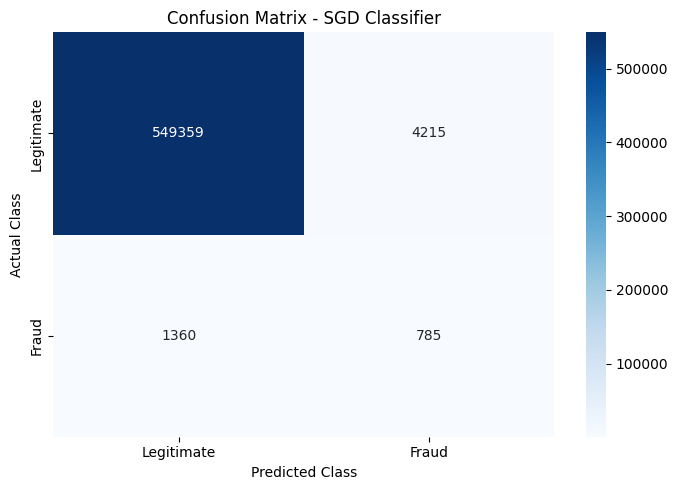

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sgd_cm = confusion_matrix(y_test, sgd_best_pred)

print(sgd_cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - SGD Classifier")
plt.tight_layout()
plt.show()

In [44]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Best Threshold"
    ],
    "Value": [
        sgd_best_accuracy,
        sgd_best_precision,
        sgd_best_recall,
        sgd_best_f1,
        sgd_roc_auc,
        sgd_pr_auc,
        best_sgd_threshold
    ]
})

print(final_results.to_string(index=False))

        Metric    Value
      Accuracy 0.989968
     Precision 0.157000
        Recall 0.365967
      F1-Score 0.219734
       ROC-AUC 0.843524
        PR-AUC 0.077883
Best Threshold 0.910000


In [45]:
import joblib

joblib.dump(sgd_model, "/content/credit_card_fraud_sgd_model.pkl")
joblib.dump(preprocessor, "/content/credit_card_fraud_preprocessor.pkl")

print("SGD model saved successfully!")
print("Preprocessor saved successfully!")

SGD model saved successfully!
Preprocessor saved successfully!


In [46]:
import joblib

loaded_model = joblib.load("/content/credit_card_fraud_sgd_model.pkl")
loaded_preprocessor = joblib.load("/content/credit_card_fraud_preprocessor.pkl")

print("Model loaded successfully!")
print("Preprocessor loaded successfully!")
print("Model type:", type(loaded_model))
print("Preprocessor type:", type(loaded_preprocessor))

Model loaded successfully!
Preprocessor loaded successfully!
Model type: <class 'sklearn.linear_model._stochastic_gradient.SGDClassifier'>
Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [47]:
sample_transaction = X_test.iloc[[0]]

sample_processed = loaded_preprocessor.transform(sample_transaction)

sample_prediction = loaded_model.predict(sample_processed)[0]

sample_probability = loaded_model.predict_proba(sample_processed)[0][1]

print("Predicted Class:", sample_prediction)
print("Fraud Probability:", sample_probability)

if sample_probability >= best_sgd_threshold:
    print("Prediction: Fraud")
else:
    print("Prediction: Legitimate")

Predicted Class: 0
Fraud Probability: 0.07487666165004817
Prediction: Legitimate


In [48]:
fraud_index = y_test[y_test == 1].index[0]

fraud_transaction = X_test.loc[[fraud_index]]

fraud_processed = loaded_preprocessor.transform(fraud_transaction)

fraud_prediction = loaded_model.predict(fraud_processed)[0]

fraud_probability = loaded_model.predict_proba(fraud_processed)[0][1]

print("Actual Class: Fraud")
print("Predicted Class:", fraud_prediction)
print("Fraud Probability:", fraud_probability)

if fraud_probability >= best_sgd_threshold:
    print("Prediction: Fraud")
else:
    print("Prediction: Legitimate")

Actual Class: Fraud
Predicted Class: 0
Fraud Probability: 0.06632443171409554
Prediction: Legitimate


In [49]:
fraud_indices = y_test[y_test == 1].index[:10]

fraud_samples = X_test.loc[fraud_indices]

fraud_samples_processed = loaded_preprocessor.transform(fraud_samples)

fraud_sample_probabilities = loaded_model.predict_proba(
    fraud_samples_processed
)[:, 1]

fraud_sample_predictions = (
    fraud_sample_probabilities >= best_sgd_threshold
).astype(int)

fraud_demo = pd.DataFrame({
    "Actual": y_test.loc[fraud_indices].values,
    "Predicted": fraud_sample_predictions,
    "Fraud_Probability": fraud_sample_probabilities
})

print(fraud_demo.to_string(index=False))

 Actual  Predicted  Fraud_Probability
      1          0           0.066324
      1          1           0.980531
      1          1           0.933696
      1          1           0.993631
      1          1           0.953693
      1          0           0.094955
      1          1           0.996001
      1          1           0.974784
      1          1           0.984475
      1          1           0.988816


In [50]:
comparison_metrics = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

comparison_metrics

,Model,Metric,Score
0,Logistic Regression,Accuracy,0.909566
1,SGD Classifier,Accuracy,0.925351
2,Logistic Regression,Precision,0.008901
3,SGD Classifier,Precision,0.032935
4,Logistic Regression,Recall,0.203263
5,SGD Classifier,Recall,0.646620
6,Logistic Regression,F1-Score,0.017055
7,SGD Classifier,F1-Score,0.062678
8,Logistic Regression,ROC-AUC,0.537153
9,SGD Classifier,ROC-AUC,0.843524


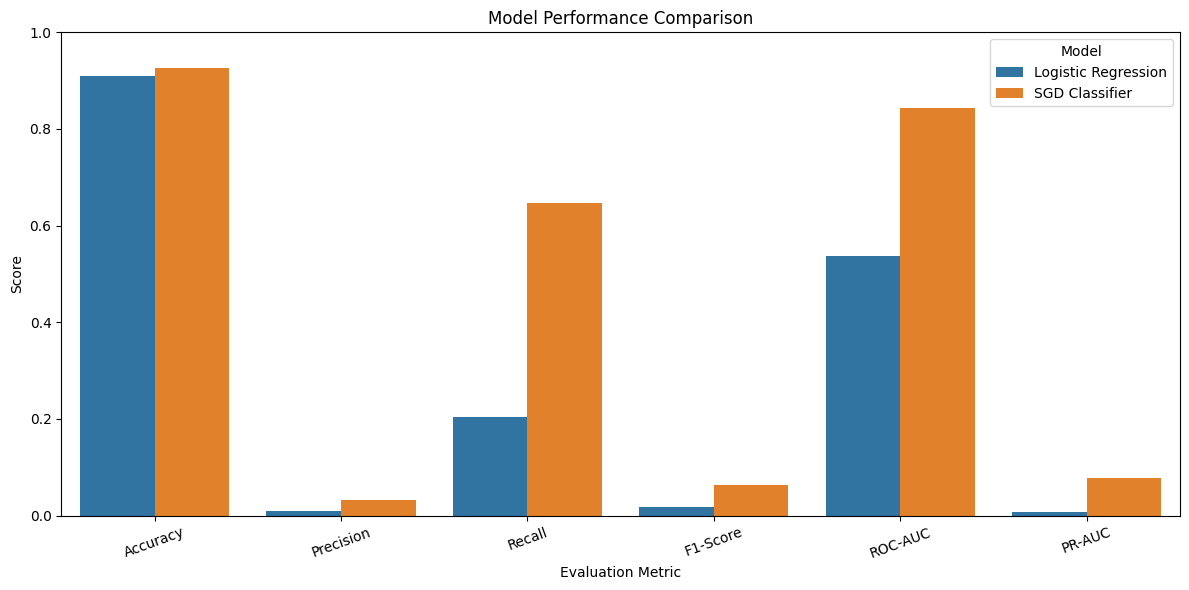

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_metrics,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

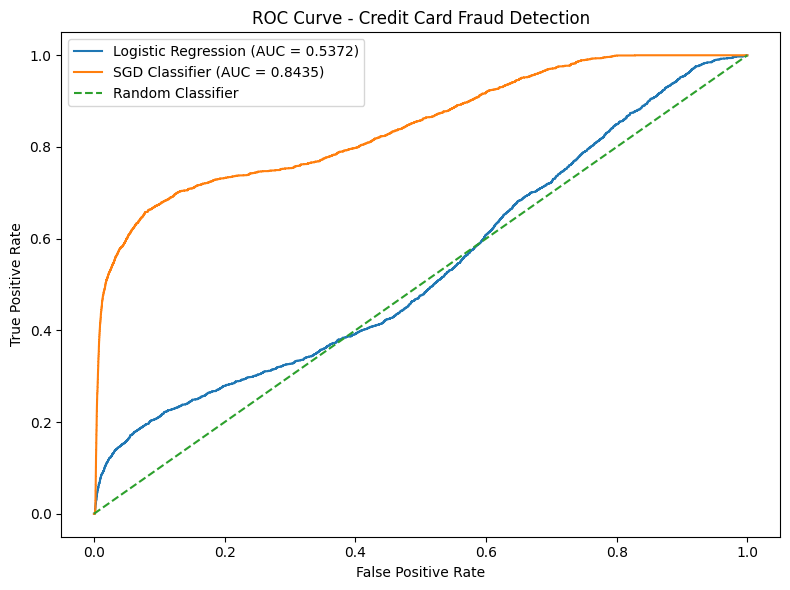

In [52]:
from sklearn.metrics import roc_curve

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, y_prob)
sgd_fpr, sgd_tpr, _ = roc_curve(y_test, sgd_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    sgd_fpr,
    sgd_tpr,
    label=f"SGD Classifier (AUC = {sgd_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.tight_layout()
plt.show()

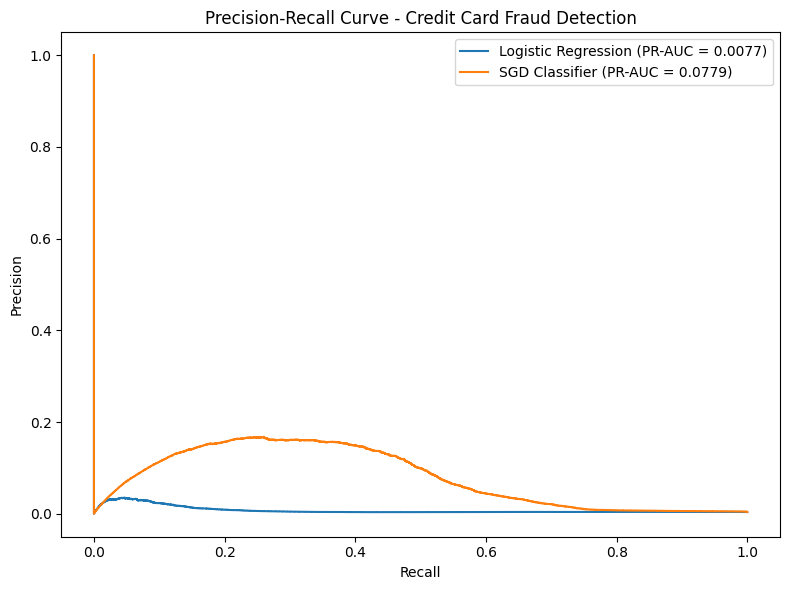

In [53]:
from sklearn.metrics import precision_recall_curve

logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

sgd_precision_curve, sgd_recall_curve, _ = precision_recall_curve(
    y_test,
    sgd_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label=f"Logistic Regression (PR-AUC = {pr_auc:.4f})"
)

plt.plot(
    sgd_recall_curve,
    sgd_precision_curve,
    label=f"SGD Classifier (PR-AUC = {sgd_pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Credit Card Fraud Detection")
plt.legend()
plt.tight_layout()
plt.show()

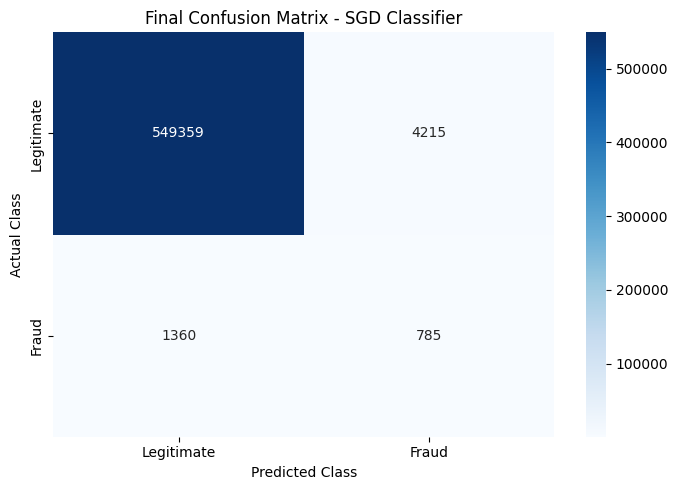

True Negatives : 549359
False Positives: 4215
False Negatives: 1360
True Positives : 785


In [54]:
from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(y_test, sgd_best_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Final Confusion Matrix - SGD Classifier")
plt.tight_layout()
plt.show()

print("True Negatives :", final_cm[0, 0])
print("False Positives:", final_cm[0, 1])
print("False Negatives:", final_cm[1, 0])
print("True Positives :", final_cm[1, 1])

In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        sgd_best_pred,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9975    0.9924    0.9950    553574
       Fraud     0.1570    0.3660    0.2197      2145

    accuracy                         0.9900    555719
   macro avg     0.5773    0.6792    0.6073    555719
weighted avg     0.9943    0.9900    0.9920    555719



In [56]:
final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Selected Threshold"
    ],
    "Value": [
        f"{sgd_best_accuracy * 100:.2f}%",
        f"{sgd_best_precision * 100:.2f}%",
        f"{sgd_best_recall * 100:.2f}%",
        f"{sgd_best_f1 * 100:.2f}%",
        f"{sgd_roc_auc * 100:.2f}%",
        f"{sgd_pr_auc * 100:.2f}%",
        f"{best_sgd_threshold:.2f}"
    ]
})

print(final_summary.to_string(index=False))

            Metric  Value
          Accuracy 99.00%
         Precision 15.70%
            Recall 36.60%
          F1-Score 21.97%
           ROC-AUC 84.35%
            PR-AUC  7.79%
Selected Threshold   0.91


In [57]:
import os

print("Saved Model:", os.path.exists("/content/credit_card_fraud_sgd_model.pkl"))
print("Saved Preprocessor:", os.path.exists("/content/credit_card_fraud_preprocessor.pkl"))

print("Model Size (MB):", round(
    os.path.getsize("/content/credit_card_fraud_sgd_model.pkl") / (1024 * 1024),
    2
))

print("Preprocessor Size (MB):", round(
    os.path.getsize("/content/credit_card_fraud_preprocessor.pkl") / (1024 * 1024),
    2
))

Saved Model: True
Saved Preprocessor: True
Model Size (MB): 0.02
Preprocessor Size (MB): 0.04


In [58]:
test_transaction = X_test.iloc[[0]]

test_processed = loaded_preprocessor.transform(test_transaction)

test_probability = loaded_model.predict_proba(test_processed)[0][1]

test_final_prediction = int(
    test_probability >= best_sgd_threshold
)

print("Fraud Probability:", round(test_probability, 6))
print("Selected Threshold:", best_sgd_threshold)

if test_final_prediction == 1:
    print("Final Prediction: Fraud")
else:
    print("Final Prediction: Legitimate")

Fraud Probability: 0.074877
Selected Threshold: 0.91
Final Prediction: Legitimate
